# OLS vs Gradient Descent in Linear Regression

## Objective

The objective of this notebook is to understand how Linear Regression models are optimized using Ordinary Least Squares (OLS) and Gradient Descent. The notebook compares direct mathematical optimization with iterative learning and analyzes how model coefficients converge during training.

In [167]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [168]:
# load dataset
data = pd.read_csv('/content/drive/My Drive/Advertising.csv')
data

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


## OLS
1. OLS is a closed-form solution, it is a mathematical expression that provides an exact answer to the problem using finite no. of standard operations (roots, logs, exponents, multiplication, division, addition, substraction and trignometric functions)
2. for e.g. arithmetic series sum formula -> (n*(n+1))/2
3. In multiple linear regression, the OLS formula to find optimal value of cofficients is:
$$
\beta = (X^TX)^{-1}X^Ty
$$
4. What does optimal value means, so Loss Function:
$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - (b_0 + b_1X_1 + b_2X_2 + b_3X_3))^2
$$
finding optimal values of cofficient means finding such values of the cofficients such that Loss Function would be minimum for the model


In [169]:
X = data[['TV', 'Radio', 'Newspaper']]
print(type(X))
print(X.shape)
print(X.head())

<class 'pandas.core.frame.DataFrame'>
(200, 3)
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4


In [170]:
y = data['Sales']
print(type(y))
print(y.shape)
print(y.head())

<class 'pandas.core.series.Series'>
(200,)
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


In [171]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [172]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [173]:
lr.fit(x_train, y_train)

LinearRegression()

In [174]:
print(f'OLS Cofficients -> {lr.coef_}')
print(f'OLS Intercept -> {lr.intercept_}')

OLS Cofficients -> [0.04405928 0.1992875  0.00688245]
OLS Intercept -> 2.7089490925159065


In [175]:
y_pred = lr.predict(x_test)

In [176]:
from sklearn.metrics import mean_squared_error, r2_score
print(f'OLS Root Mean Squared Error -> {np.sqrt(mean_squared_error(y_test, y_pred))}')
print(f'OLS R2 Score -> {r2_score(y_test, y_pred)}')

OLS Root Mean Squared Error -> 1.9485372043446387
OLS R2 Score -> 0.8609466508230368


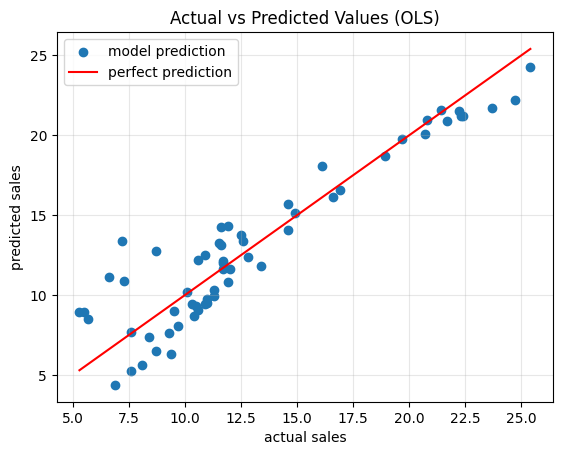

In [177]:
plt.scatter(y_test, y_pred, label='model prediction')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='r',
    label='perfect prediction'
)

plt.xlabel("actual sales")
plt.ylabel("predicted sales")
plt.title("Actual vs Predicted Values (OLS)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Gradient Descent

1. Gradient Descent iteratively approaches the optimal solution through repeated parameter updates.
2. Gradient Descent starts with random coefficients and gradually updates them in the direction that reduces prediction error basically tries to find minima of the function 
3. b_new = b_old - (learning_rate*slope), this is the formula to find the new value of the cofficients! where learning rate plays an important role in the stability and convergence speed of Gradient Descent. 

In [178]:
# scale the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
print(x_train_scaled.shape)
print(x_train_scaled[:6])

(140, 3)
[[ 1.53003874 -0.8862929  -1.16598019]
 [ 0.34103865 -0.17314426 -0.40960132]
 [-0.5202089  -0.42000341  0.39526337]
 [-1.58600275  0.79372072  1.71892638]
 [ 1.60659408 -1.33201081 -1.06415995]
 [-1.63863454 -0.51600419 -0.39505557]]


## Why Feature Scaling is Important for Gradient Descent

Gradient Descent updates model coefficients iteratively using gradients. When features have very different numerical ranges, some gradients become much larger than others, causing unstable updates and poor convergence behavior.

In the Advertising dataset, TV advertising values are much larger than Radio and Newspaper values. Without scaling, Gradient Descent produced unstable optimization behavior and failed to converge properly.

Feature scaling standardizes all features to a similar range, resulting in more stable and efficient optimization.

In [179]:
print(y_train.shape)
y_gd = y_train.values.reshape(-1, 1)
print(y_gd.shape)

(140,)
(140, 1)


In [180]:
# define random values of intercept and slopes
b = 0
slopes = np.ones(x_train_scaled.shape[1]).reshape(-1, 1)
print(slopes.shape)
print(slopes)

(3, 1)
[[1.]
 [1.]
 [1.]]


In [181]:
epochs = 1000
learning_rate = 0.01
n = len(x_train_scaled)
losses = []

for i in range(epochs):
    y_pred_gd = np.dot(x_train_scaled, slopes) + b

    # intercept
    d_b = -2 * np.mean(y_gd - y_pred_gd)
    b = b - (learning_rate * d_b)

    # cofficients
    d_slope = -2/n * np.dot(x_train_scaled.T, (y_gd - y_pred_gd))
    slopes = slopes - (learning_rate * d_slope)

    # loss function
    loss_func = np.mean((y_gd - y_pred_gd)**2)
    losses.append(loss_func)

print(f'Loss -> {loss_func}')
print(f'GD Intercept -> {b}')
print(f'GD Cofficients -> {slopes}')

Loss -> 2.4793551789127
GD Intercept -> 14.49714283274464
GD Cofficients -> [[3.683341  ]
 [2.90625015]
 [0.14194996]]


The intercept and coefficient values obtained from Gradient Descent do not directly match the OLS values because Gradient Descent was trained on scaled features, while the original OLS model was trained on unscaled data.

Feature scaling changes the numerical representation of the input variables, which also changes the coefficient magnitudes and intercept values. However, when OLS is trained on the same scaled dataset, both OLS and Gradient Descent produce very similar coefficient and intercept values.

In [182]:
lr.fit(x_train_scaled, y_train)

LinearRegression()

In [183]:
print(f'OLS Intercept (with scaled features) -> {lr.intercept_}')
print(f'OLS Cofficients (with scaled features) -> {lr.coef_}')

OLS Intercept (with scaled features) -> 14.497142857142858
OLS Cofficients (with scaled features) -> [3.68334078 2.90625242 0.14194772]


After training OLS on the same scaled dataset, the coefficient and intercept values became very close to those obtained from Gradient Descent. This confirms that both optimization methods converged toward a similar Linear Regression solution.

In [184]:
y_pred_GD = np.dot(x_test_scaled, slopes) + b

In [185]:
print(f'GD Root Mean Squared Error -> {np.sqrt(mean_squared_error(y_test, y_pred_GD))}')
print(f'GD R2 Score -> {r2_score(y_test, y_pred_GD)}')


GD Root Mean Squared Error -> 1.948537208126421
GD R2 Score -> 0.8609466502832785


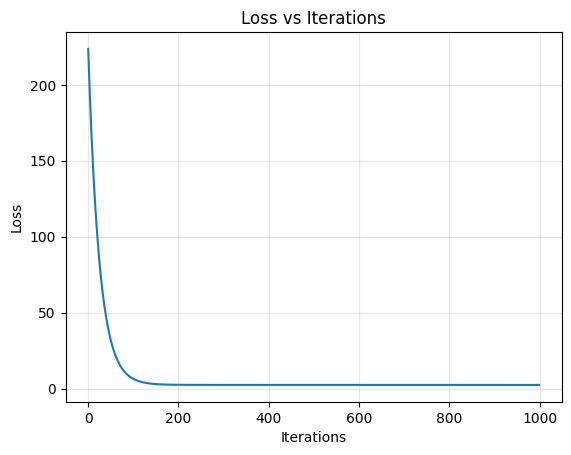

In [186]:
plt.plot(range(epochs), losses)

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations")
plt.grid(alpha=0.3)
plt.show()

The loss decreases rapidly during the initial iterations and gradually stabilizes, indicating that Gradient Descent is successfully converging toward an optimal solution.

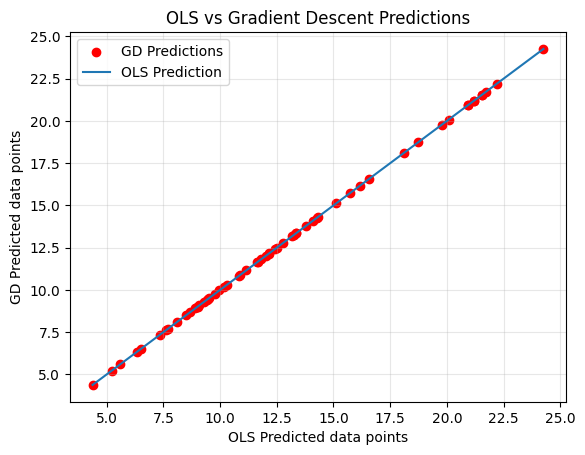

In [187]:
plt.scatter(y_pred, y_pred_GD, color='r', label='GD Predictions')
plt.plot(
    [y_pred.min(), y_pred.max()],
    [y_pred.min(), y_pred.max()],
    label='OLS Prediction'
)

plt.title('OLS vs Gradient Descent Predictions')
plt.xlabel('OLS Predicted data points')
plt.ylabel('GD Predicted data points')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## OLS vs Gradient Descent Prediction Comparison

The comparison plot shows that the predictions generated by Gradient Descent lie very close to the diagonal reference line, indicating strong agreement with the OLS predictions.

This suggests that the custom Gradient Descent implementation successfully converged to a solution similar to the closed-form OLS solution. Although the optimization approaches are different, both methods minimize the same Linear Regression objective function, resulting in highly similar predictions.

## Why Gradient Descent Becomes Important

Although OLS provides an exact closed-form solution for Linear Regression, it requires computing the inverse of the matrix:
$$
\beta = (X^TX)^{-1}X^Ty
$$

For small datasets, this is usually fast and efficient. However, as the number of features and dataset size increase, matrix inversion becomes computationally expensive and memory-intensive.

In some cases, the matrix may also become singular or nearly singular due to multicollinearity, making the inverse unstable or impossible to compute reliably.

Gradient Descent avoids direct matrix inversion by learning the coefficients iteratively through optimization. This makes Gradient Descent more scalable and practical for large datasets and high-dimensional machine learning problems.

# Final Comparison: OLS vs Gradient Descent

| Aspect | OLS Regression | Gradient Descent |
|---|---|---|
| Optimization Approach | Direct mathematical solution | Iterative optimization |
| Learning Process | Solves coefficients in one step | Updates coefficients gradually |
| Formula Type | Closed-form solution | Numerical optimization |
| Training Speed (Small Dataset) | Faster | Slower |
| Sensitivity to Feature Scaling | Low | High |
| Convergence Issues | Generally stable | Can diverge with improper learning rate |
| Need for Learning Rate | No | Yes |
| Interpretability | High | High |
| Final Performance | Strong | Very similar to OLS |
| Coefficient Values | Exact analytical solution | Approximate converged solution |


# Final Observations

- OLS and Gradient Descent both optimize the Linear Regression objective function using different approaches.
- OLS computes coefficients directly using a closed-form mathematical solution, while Gradient Descent learns coefficients iteratively through optimization.
- Feature scaling was important for stable Gradient Descent convergence because the dataset features had different numerical ranges.
- The loss decreased gradually during training, indicating successful convergence of the Gradient Descent algorithm.
- Both OLS and Gradient Descent produced very similar predictions and evaluation metrics on the Advertising dataset.
- This demonstrates that different optimization methods can converge to similar solutions for the same regression problem.